# Churn Prediction — Model Training & Evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
from xgboost import XGBClassifier

df = pd.read_csv('../data/churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
print('Shape:', df.shape)
df.head()

Shape: (7032, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Feature engineering
df_model = df.drop(columns=['customerID'])

# Encode binary columns
binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling','Churn']
for col in binary_cols:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

# One-hot encode multi-class columns
cat_cols = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
            'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
            'Contract','PaymentMethod']
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

print('Features:', df_model.shape[1]-1)
print('Sample columns:', df_model.columns.tolist()[:10])

Features: 30
Sample columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [3]:
# Train/test split
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numerical features
scaler = StandardScaler()
num_cols = ['tenure','MonthlyCharges','TotalCharges']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (5625, 30)
Test size: (1407, 30)


In [4]:
# Train all three models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {
        'model': model,
        'auc': auc,
        'f1': report['1']['f1-score'],
        'precision': report['1']['precision'],
        'recall': report['1']['recall'],
        'y_prob': y_prob
    }
    print(f'{name}: AUC={auc:.3f} F1={report["1"]["f1-score"]:.3f}')

Logistic Regression: AUC=0.836 F1=0.609


Random Forest: AUC=0.815 F1=0.560
XGBoost: AUC=0.820 F1=0.568


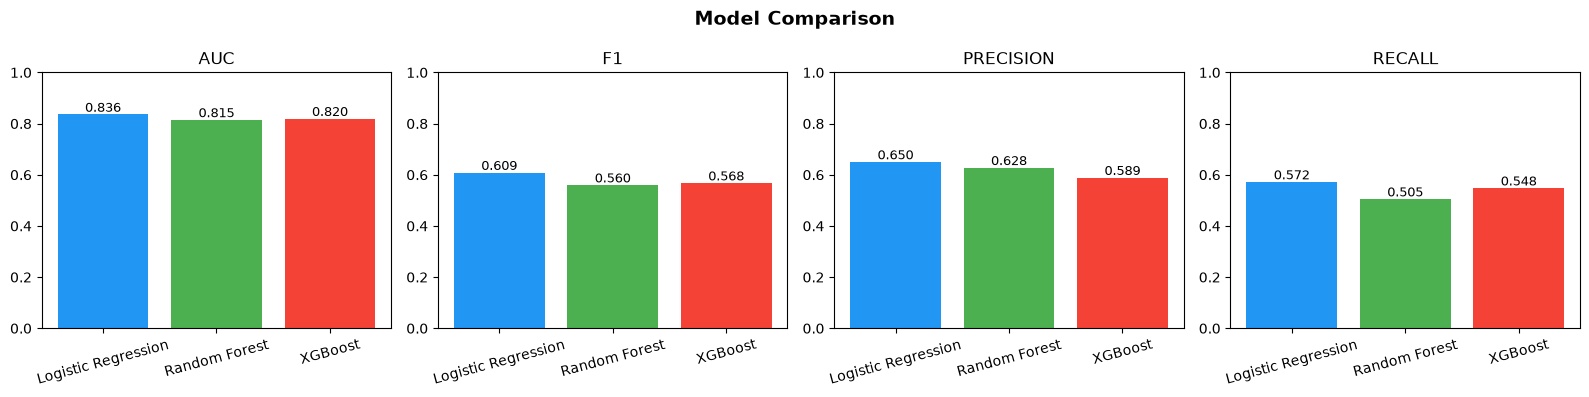

In [5]:
# Model comparison chart
metrics = ['auc','f1','precision','recall']
model_names = list(results.keys())

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = ['#2196F3','#4CAF50','#F44336']

for i, metric in enumerate(metrics):
    values = [results[m][metric] for m in model_names]
    bars = axes[i].bar(model_names, values, color=colors)
    axes[i].set_title(metric.upper())
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

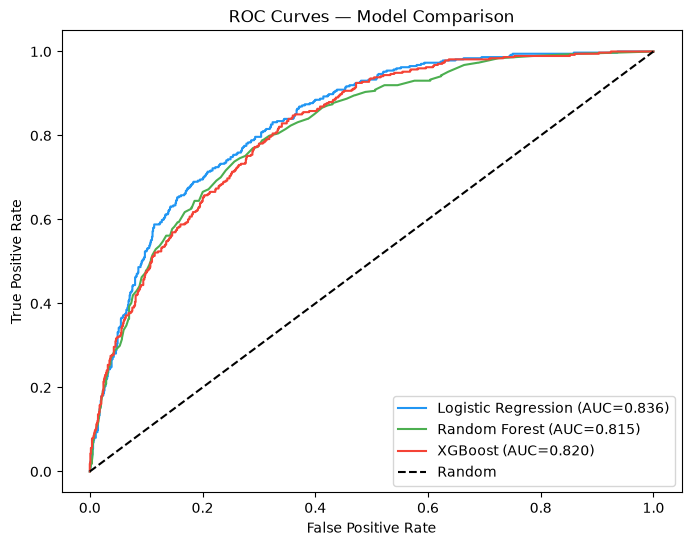

In [6]:
# ROC curves
plt.figure(figsize=(8, 6))
colors = ['#2196F3','#4CAF50','#F44336']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, color=color, label=f"{name} (AUC={res['auc']:.3f})")

plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend()
plt.savefig('../data/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

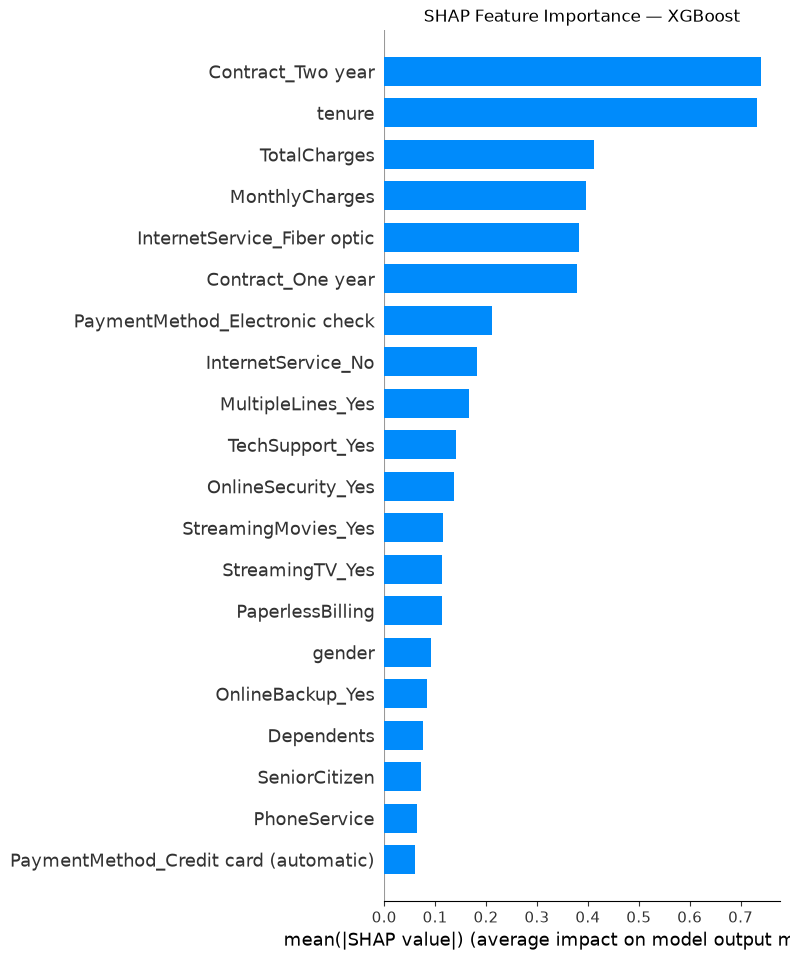

In [7]:
# SHAP explainability on best model (XGBoost)
best_model = results['XGBoost']['model']

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — XGBoost')
plt.savefig('../data/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

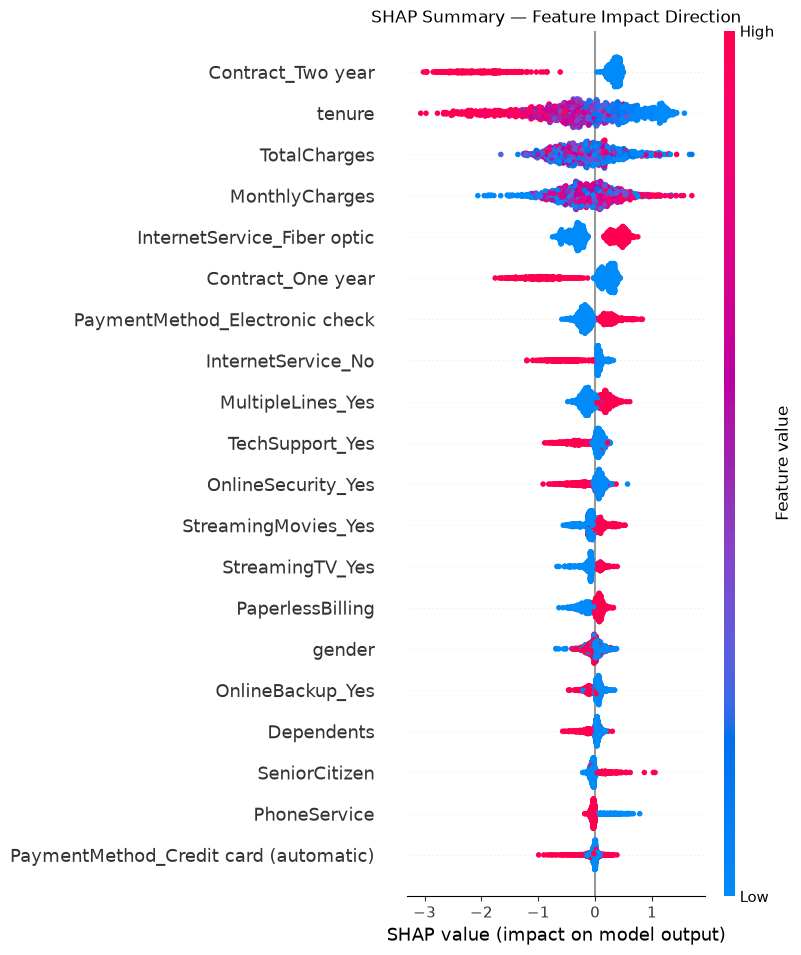

In [8]:
# SHAP beeswarm plot — shows direction of impact
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary — Feature Impact Direction')
plt.savefig('../data/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Save model and scaler for Streamlit app
import os
os.makedirs('../models', exist_ok=True)

with open('../models/xgb_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)

print('Model saved to models/xgb_model.pkl')
print('Scaler saved to models/scaler.pkl')
print('Features saved to models/feature_names.pkl')

Model saved to models/xgb_model.pkl
Scaler saved to models/scaler.pkl
Features saved to models/feature_names.pkl


## Results summary
- XGBoost outperforms Logistic Regression and Random Forest on AUC and F1
- Top churn drivers (SHAP): tenure, MonthlyCharges, Contract type
- Model saved for deployment in Streamlit app